# Notebook Objectives

This notebook computes neural values for one session. For all sessions, we do the same in ```neural_value_RUN_all_sessions.py```, results shown in ```neural_value_all_sessions.ipynb```.

Results include:
* Neural value vs. behavior (last 3 outcomes, behavioral value, long history, etc)
* Change in neural value, etc

---
# Setup


In [3]:
from neural_value_helpers import *
from popy.config import COLORS

In [ ]:
##% data loading
def load_mega_custom(monkey=None, area=None, subregion=None, downsample=True):
    # load data (meta session)
    floc = os.path.join(PATH, 'data', 'processed', 'neural_data', 'meta_rates_history')
    neural_dataset =  xr.open_dataset(floc + '/meta_rates.nc')

    if area is not None:
        neural_dataset = neural_dataset.sel(unit=neural_dataset.area == area)
    if subregion is not None:
        neural_dataset = neural_dataset.sel(unit=neural_dataset.subregion == subregion)

    if monkey is not None:
        neural_dataset = neural_dataset.sel(unit=neural_dataset.monkey == monkey)

    # use only time points of every .1 s
    if downsample:
        time_vector = neural_dataset.time.values
        time_vector = np.unique(np.round(time_vector, 1))  # round to 1 decimal place to avoid floating point issues
        neural_dataset = neural_dataset.sel(time=time_vector, method='nearest')

    # add coordinates (should be added during the dataset creation)
    neural_dataset = neural_dataset.assign_coords(R_1=('trial_id', [0 if hist in [0, 1, 2, 3] else 1 for hist in neural_dataset.history_of_feedback.values]))
    neural_dataset = neural_dataset.assign_coords(R_2=('trial_id', [0 if hist in [0, 1, 4, 5] else 1 for hist in neural_dataset.history_of_feedback.values]))
    neural_dataset = neural_dataset.assign_coords(R_3=('trial_id', [0 if hist in [0, 2, 4, 6] else 1 for hist in neural_dataset.history_of_feedback.values]))
    neural_dataset = neural_dataset.assign_coords(R_1=('trial_id', neural_dataset.history_of_feedback.values))
    neural_dataset = neural_dataset.assign_coords(fb_sequence_m1=('trial_id', neural_dataset.history_of_feedback.values%4))
    neural_dataset = neural_dataset.assign_coords(time_m1=('time', neural_dataset.time.values + 7.5))

    # normalize firing rates (z-score) and remove units with low firing rates
    threshold = 1  # Hz
    units_to_remove = []
    normalized_data = np.zeros_like(neural_dataset.firing_rates.data)  # Create a copy to avoid modifying the original data
    for i, unit in enumerate(neural_dataset.unit.values):  # Loop through each neuron
        # Get all data for this neuron across trials and timepoints
        unit_data = neural_dataset.firing_rates.sel(unit=unit).values
        
        # Calculate mean and std across all values for this neuron
        mean_val = np.mean(unit_data)
        std_val = np.std(unit_data)
        
        # Z-score normalize and store in the output array
        if mean_val < threshold:
            units_to_remove.append(unit)
        elif std_val == 0:
            raise ValueError(f"Standard deviation is zero for unit {unit}. Not possible.")
        else:
            z_scored_data = (unit_data - mean_val) / std_val        
            normalized_data[:, i, :] = z_scored_data
    #neural_dataset.firing_rates.values = normalized_data
    neural_dataset['firing_rates'] = (neural_dataset.firing_rates.dims, normalized_data)

    neural_dataset = neural_dataset.sel(unit=~neural_dataset.unit.isin(units_to_remove))
    print(f"Removed {len(units_to_remove)} units with mean firing rate < {threshold} Hz")

    return neural_dataset


In [5]:
neural_dataset_all = load_mega_custom(downsample=True, monkey='ka')
target = 'R_1'  # target for the decoder, can be R_1, R_2, R_3, or switch

# create a new figure: the accuracies across areas
neural_dataset_all

Removed 187 units with mean firing rate < 1 Hz


<xarray.Dataset>
Dimensions:              (unit: 1559, time: 151, trial_id: 160)
Coordinates: (12/17)
    unit_id_original     (unit) int64 ...
    channel              (unit) int64 ...
    monkey               (unit) object 'ka' 'ka' 'ka' 'ka' ... 'ka' 'ka' 'ka'
    session              (unit) object ...
    area                 (unit) object ...
    subregion            (unit) object ...
    ...                   ...
    R_1                  (trial_id) int64 0 0 0 0 0 0 0 0 0 ... 1 1 1 1 1 1 1 1
    R_2                  (trial_id) int64 0 0 0 0 0 0 0 0 0 ... 1 1 1 1 1 1 1 1
    R_3                  (trial_id) int64 0 0 0 0 0 0 0 0 0 ... 1 1 1 1 1 1 1 1
    fb_sequence          (trial_id) float64 0.0 0.0 0.0 0.0 ... 7.0 7.0 7.0 7.0
    fb_sequence_m1       (trial_id) float64 0.0 0.0 0.0 0.0 ... 3.0 3.0 3.0 3.0
    time_m1              (time) float64 0.0 0.1 0.2 0.3 ... 14.7 14.8 14.9 14.99
Data variables:
    firing_rates         (trial_id, unit, time) float64 -0.4934 ... -1.355
Attributes:
    bin_size:  0.01

---
# Get the across time thing (alongside the decoding performance and projection, but in low resolution)

In [ ]:
for subregion in np.unique(neural_dataset_all.subregion.values):
    neural_dataset_subregion = neural_dataset_all.sel(unit=neural_dataset_all.subregion==subregion)
    ## 1. plot monkey average
    #results, weights, data_projected, pvalue = time_resolved_decoder(neural_dataset, target='R_1', t_project=t_interest_fit)
    decodability_matrix, data_projected = time_resolved_decoder_all_time(neural_dataset_subregion, target=target, across_time=False)

    fig, ax = plot_projected_data(data_projected, t_interest_value=None, n_extra_trials=(-1, 0), xlim=[-5, 5], paper_format=True)
    
    ax.set_title(f'both monkeys {subregion} ')
    plt.show()
    plt.close(fig)

    '''## 2. prot per monkey
    for monkey in np.unique(neural_dataset_all.monkey.values):
        neural_dataset = neural_dataset_subregion.sel(unit=neural_dataset_subregion.monkey==monkey)
        #results, weights, data_projected, pvalue = time_resolved_decoder(neural_dataset, target='R_1', t_project=t_interest_fit)
        decodability_matrix, data_projected = time_resolved_decoder_all_time(neural_dataset, target='R_1', across_time=False)

        fig, ax = plot_projected_data(data_projected, t_interest_value=None, n_extra_trials=(-1, 0), xlim=[-5, 5], paper_format=True)
        ax.set_title(f'{monkey} {subregion}')
        plt.show()
        plt.close(fig)'''


# Get projections in high resolution

In [ ]:
neural_dataset_all = load_mega_custom(downsample=False)

# create a new figure: the accuracies across areas

for subregion in np.unique(neural_dataset_all.subregion.values):
    neural_dataset_subregion = neural_dataset_all.sel(unit=neural_dataset_all.subregion==subregion)
    ## 1. plot monkey average
    #results, weights, data_projected, pvalue = time_resolved_decoder(neural_dataset, target='R_1', t_project=t_interest_fit)
    _, data_projected = time_resolved_decoder_all_time(neural_dataset_subregion, target='R_1', across_time=False)

    fig, ax = plot_projected_data(data_projected, t_interest_value=None, n_extra_trials=(-1, 0), xlim=[-5, 5], paper_format=True)
    ax.set_title(f'both monkeys {subregion} ')
    fig.savefig(f'figs/neural_value/mega_session/KA&PO_mega_session_{subregion}_projected_data.svg', bbox_inches='tight', transparent=True)
    plt.show()
    plt.close(fig)

    ## 2. prot per monkey
    for monkey in np.unique(neural_dataset_all.monkey.values):
        neural_dataset = neural_dataset_subregion.sel(unit=neural_dataset_subregion.monkey==monkey)
        #results, weights, data_projected, pvalue = time_resolved_decoder(neural_dataset, target='R_1', t_project=t_interest_fit)
        _, data_projected = time_resolved_decoder_all_time(neural_dataset, target='R_1', across_time=False)

        fig, ax = plot_projected_data(data_projected, t_interest_value=None, n_extra_trials=(-1, 0), xlim=[-5, 5], paper_format=True)
        ax.set_title(f'{monkey} {subregion}')
        fig.savefig(f'figs/neural_value/mega_session/{monkey}_mega_session_{subregion}_projected_data.svg', bbox_inches='tight', transparent=True)
        plt.show()
        plt.close(fig)


# analyse only the decoding performance (not the across time thing)

In [7]:
neural_dataset_all = load_mega_custom(downsample=True)

# create a new figure: the accuracies across areas

decodabilities = {}
for subregion in np.unique(neural_dataset_all.subregion.values):
    neural_dataset_subregion = neural_dataset_all.sel(unit=neural_dataset_all.subregion==subregion)
    ## 1. plot monkey average
    #results, weights, data_projected, pvalue = time_resolved_decoder(neural_dataset, target='R_1', t_project=t_interest_fit)
    decodability_matrix, data_projected = time_resolved_decoder_all_time(neural_dataset_subregion, target='R_1', across_time=False)

    decodabilities[str(subregion)] = data_projected


Removed 332 units with mean firing rate < 1 Hz


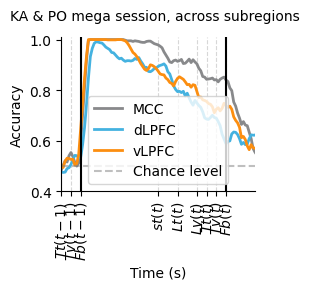

In [18]:
fig, ax = plt.subplots(figsize=(2.5, 2))

for subregion, data_projected in decodabilities.items():
    data = data_projected.decodability.values
    data = np.convolve(data, np.ones((5,))/5, mode='same')
    ax.plot(data_projected.time.values, data, label=subregion, color=COLORS[subregion], lw=2)


ax.axhline(y=0.5, color='grey', linestyle='--', alpha=0.5, label='Chance level')
    
plot_keypoints(ax, (-1, 0), mark_event='Fb', xlabels='events')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.5, linestyle='--', axis='x')
ax.set_xlim([-5, 5])
ax.set_ylim([0.4, 1.01])
ax.set_xlabel('Time (s)')
ax.set_ylabel('Accuracy', fontsize=10)
ax.legend()

# save figure
plt.suptitle(f'KA & PO mega session, across subregions', fontsize=10, y=1.02)
#fig.savefig(f'figs/neural_value/mega_session/KA&PO_mega_session_decodability.svg', bbox_inches='tight', transparent=True)
plt.show()


## Extract neural value

In [19]:
data_projected

<xarray.DataArray (trial_id: 160, time: 151)>
array([[ 2.79440503,  2.64851018,  4.78428055, ..., -1.45406671,
        -0.99507383,  2.57977893],
       [ 2.44692765,  3.06999983,  1.71537902, ..., -2.63362941,
        -5.56822384, -4.40953414],
       [ 1.63465334,  1.22287934,  2.03499472, ..., -1.38716872,
         1.37170241,  0.76377236],
       ...,
       [ 0.93005381,  2.2787331 ,  7.81839472, ...,  1.37260712,
         2.50426417,  0.75762356],
       [-2.3573571 ,  3.86765638, -0.20632453, ...,  4.53619071,
         3.0208318 , -4.49999392],
       [ 1.79573793,  0.37547601, -2.28017397, ..., -0.96548578,
         4.60385455, -1.56183325]])
Coordinates:
    history_of_feedback  (trial_id) float64 0.0 0.0 0.0 0.0 ... 7.0 7.0 7.0 7.0
  * trial_id             (trial_id) int64 0 1 2 3 4 5 ... 155 156 157 158 159
    R_1                  (trial_id) int64 0 0 0 0 0 0 0 0 0 ... 1 1 1 1 1 1 1 1
    R_2                  (trial_id) int64 0 0 0 0 0 0 0 0 0 ... 1 1 1 1 1 1 1 1
    R_3                  (trial_id) int64 0 0 0 0 0 0 0 0 0 ... 1 1 1 1 1 1 1 1
    fb_sequence          (trial_id) float64 0.0 0.0 0.0 0.0 ... 7.0 7.0 7.0 7.0
    fb_sequence_m1       (trial_id) float64 0.0 0.0 0.0 0.0 ... 3.0 3.0 3.0 3.0
  * time                 (time) float64 -7.5 -7.4 -7.3 -7.2 ... 7.2 7.3 7.4 7.49
    epoch                (time) float64 0.0 0.0 0.0 0.0 0.0 ... 5.0 5.0 5.0 5.0
    time_m1              (time) float64 0.0 0.1 0.2 0.3 ... 14.7 14.8 14.9 14.99
    decodability         (time) float64 0.5375 0.5375 0.525 ... 0.5312 0.575

In [34]:
def plot_projected_data_R_1(data_projected, t_interest_value=None, normalize=False, n_extra_trials=(0, 1), xlim=None, paper_format=False, ax=None):
    # project to axis
    if paper_format:
        plt.rcParams.update({'font.size': 8})
        h = 1.7  # in cm
        w = 2.5
        linewidth = 2
    else:
        plt.rcParams.update({'font.size': 12})
        h = 6  # in cm
        w = 8  # in cm
        linewidth = 1.5

    unique_R_1s = np.sort(np.unique(data_projected.R_1.data))

    colors = value_gradient(len(unique_R_1s))

    if ax is None:
        fig, ax = plt.subplots(figsize=(w, h))

    # 500 ms for convolution
    dt = data_projected.time.values[1] - data_projected.time.values[0]
    n_convolution_bins = int(.5 / dt)
    window = np.ones(n_convolution_bins) / n_convolution_bins

    time_vector = data_projected.time.values


    # bwr colormap, n=8 sampples RdYlGn
    alphas = [1-i for i in np.linspace(0, 1, len(unique_R_1s))]
    labels = ["[-, -, -]", "[+, -, -]", "[-, +, -]", "[+, +, -]", "[-, -, +]", "[+, -, +]", "[-, +, +]", "[+, +, +]"]
        
    for i, label in enumerate(unique_R_1s):
        class_mean = np.mean(data_projected.where(data_projected.R_1 == label), axis=0)
        class_mean_smoothed = ndimage.convolve(class_mean, window, mode='nearest')
        ax.plot(time_vector, class_mean_smoothed, color=colors[i], label=labels[i], linewidth=linewidth, zorder=10)

    if t_interest_value is not None:
        ax.axvspan(t_interest_value[0], t_interest_value[1], color='grey', alpha=0.2, label='eval window')

    # add behav keyboints
    plot_keypoints(ax, n_extra_trials, mark_event='Fb', xlabels='events')
    # y grid only
    ax.grid(axis='x', alpha=.5, linewidth=1, linestyle='--')
    ax.axhline(0, color='k', linestyle='-', linewidth=linewidth*.75, zorder=0)

    # remove left and top spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # move legend outside
    if not paper_format:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    # save as svg
    ax.set_ylabel('$V_t$', fontsize=10)
    '''if title is not None:
        ax.set_title(title)
    else:
        ax.set_title('Neural value')'''
    
    if xlim is not None:    
        ax.set_xlim(xlim)

    return fig, ax

MCC
dLPFC
vLPFC


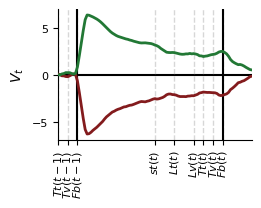

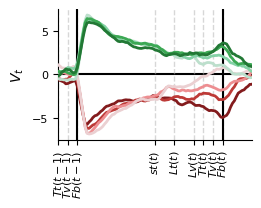

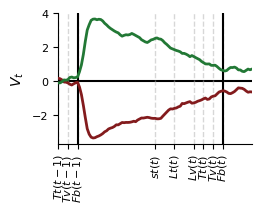

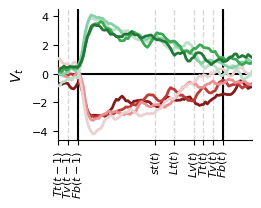

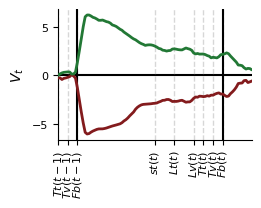

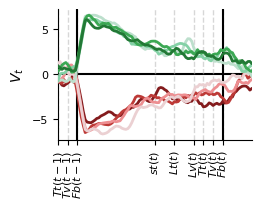

In [45]:
for subregion, data in decodabilities.items():    
    print(subregion)
    fig1, ax1 = plot_projected_data_R_1(data, t_interest_value=None, n_extra_trials=(-1, 0), paper_format=True, xlim=[-5, 5])
    fig2, ax2 = plot_projected_data(data, t_interest_value=None, n_extra_trials=(-1, 0), paper_format=True, xlim=[-5, 5])

    # save as svgs
    fig1.savefig(f'figs/KA&PO_mega_session_{subregion}_projected_data_R_1.svg', bbox_inches='tight', transparent=True)
    fig2.savefig(f'figs//KA&PO_mega_session_{subregion}_projected_data_fb_sequence.svg', bbox_inches='tight', transparent=True)

# analyse only the decoding performance (not the across time thing)

In [ ]:
neural_dataset_all = load_mega_custom_target(downsample=True, monkey='ka')
neural_dataset_all

In [ ]:

# print the number of units per area and monkey
print("Number of units per area and monkey:")
for subregion in np.unique(neural_dataset_all.subregion.values):
    for monkey in np.unique(neural_dataset_all.monkey.values):
        num_units = len(neural_dataset_all.sel(unit=(neural_dataset_all.subregion == subregion) & (neural_dataset_all.monkey == monkey)).unit)
        print(f"Area: {subregion}, Monkey: {monkey}, Units: {num_units}")

# print units per monkey
print("Number of units per monkey:")
for monkey in np.unique(neural_dataset_all.monkey.values):
    num_units = len(neural_dataset_all.sel(unit=(neural_dataset_all.monkey == monkey)).unit)
    print(f"Monkey: {monkey}, Units: {num_units}")
    

neural_dataset_all


In [ ]:
# plot example unit per target and value

for i in range(2):
    unit = neural_dataset_all.unit.values[i]  # select the first unit

    t_interest = [0, 5]  # time points of interest: cue, delay, feedback
    unit_data = neural_dataset_all.sel(unit=unit)

    # gradient from blue to red, 4 levels
    colors = ['blue', 'cyan', 'orange', 'red']

    fig, axs = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
    plt.suptitle(f'Example unit {unit}', y=1.05)

    for i, target in enumerate([1, 2, 3]):
        for value in [0, 1, 2, 3]:
            data_to_plot = unit_data.firing_rates.sel(trial_id=(unit_data.target == target) & (unit_data.fb_sequence == value)).mean(dim='trial_id')
            # smooth the data with a rolling window of 5 time points
            data_to_plot = data_to_plot.rolling(time=5, center=True).mean()
            axs[i].plot(unit_data.time, data_to_plot, label=f'Value {value}', color=colors[value])
        axs[i].set_title(f'Target {target}')
        axs[i].set_xlabel('Time (s)')
        if i == 0:
            axs[i].set_ylabel('Z-scored firing rate')
        axs[i].legend()
        plot_keypoints(axs[i])
        axs[i].grid(axis='x', alpha=0.3)
        axs[i].set_xlim(t_interest)
        sns.despine()

    plt.show()

In [ ]:
# plot example unit per target and value


t_interest = [0, 5]  # time points of interest: cue, delay, feedback

# gradient from blue to red, 4 levels
colors = ['blue', 'cyan', 'orange', 'red']

fig, axs = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
plt.suptitle(f'Example unit {unit}', y=1.05)

for i, target in enumerate([1, 2, 3]):
    for value in [0, 1, 2, 3]:
        data_to_plot = neural_dataset_all.firing_rates.sel(trial_id=(neural_dataset_all.target == target) & (neural_dataset_all.fb_sequence == value), unit=neural_dataset_all.subregion == 'dLPFC').mean(dim='unit').mean(dim='trial_id')
        # smooth the data with a rolling window of 5 time points
        #data_to_plot = data_to_plot.rolling(time=5, center=True).mean()
        axs[i].plot(neural_dataset_all.time, data_to_plot, label=f'Value {value}', color=colors[value])
    axs[i].set_title(f'Target {target}')
    axs[i].set_xlabel('Time (s)')
    if i == 0:
        axs[i].set_ylabel('Z-scored firing rate')
    axs[i].legend()
    plot_keypoints(axs[i])
    axs[i].grid(axis='x', alpha=0.3)
    axs[i].set_xlim(t_interest)
    sns.despine()

plt.show()

In [ ]:
# create a new figure: the accuracies across areas
target_temp = 'target_3'
decodabilities = {}
for subregion in np.unique(neural_dataset_all.subregion.values):
    neural_dataset_subregion = neural_dataset_all.sel(unit=neural_dataset_all.subregion==subregion)
    ## 1. plot monkey average
    #results, weights, data_projected, pvalue = time_resolved_decoder(neural_dataset, target='R_1', t_project=t_interest_fit)
    decodability_matrix, data_projected = time_resolved_decoder_all_time(neural_dataset_subregion, target=target_temp, across_time=False)

    decodabilities[str(subregion)] = data_projected


In [ ]:
fig, ax = plt.subplots(figsize=(2.5, 2))

for subregion, data_projected in decodabilities.items():
    data = data_projected.decodability.values
    #data = np.convolve(data, np.ones((50,))/50, mode='same')
    ax.plot(data_projected.time.values, data, label=subregion, color=COLORS[subregion], lw=2)


ax.axhline(y=0.5, color='grey', linestyle='--', alpha=0.5, label='Chance level')
    
plot_keypoints(ax, (-1, 0), mark_event='Fb', xlabels='events')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.5, linestyle='--', axis='x')
ax.set_xlim([-1, 6])
ax.set_ylim([0.4, 1.01])
ax.set_xlabel('Time (s)')
ax.set_ylabel('Accuracy', fontsize=10)
#ax.legend()

# save figure
plt.suptitle(f'KA & PO mega session, across subregions', fontsize=10, y=1.02)
fig.savefig(f'figs/neural_value/mega_session/KA&PO_mega_session_decodability.svg', bbox_inches='tight', transparent=True)
plt.show()


## project to subspace DVS

In [15]:
for subregion, data in decodabilities.items():    
    data_projected_temp = data.sel(trial_id=data[target_temp]==1)
    fig, ax = plot_projected_data(data_projected_temp, t_interest_value=None, n_extra_trials=(-1, 0), paper_format=True)#, xlim=[1, 6])
    # title
    ax.set_title(f'{subregion}, {target_temp}')

NameError: name 'target_temp' is not defined